# 🔐 Network Intrusion Detection System
## CNN vs RNN vs CNN+LSTM — KDD Train Dataset
### Final Year Project | Deep Learning Models Comparison

---
**What this notebook does:**
1. Loads and prepares the KDD dataset
2. Trains **CNN** model → shows accuracy
3. Trains **RNN** model → shows accuracy  
4. Trains **CNN + LSTM** (combined) model → shows accuracy
5. Compares all 3 models side by side


## Step 1 — Install Required Libraries
Run this cell first. It installs everything needed.

In [48]:
# Run this if you haven't installed these yet
# Click this cell and press Shift+Enter

import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "tensorflow", "scikit-learn", "pandas",
                       "matplotlib", "seaborn", "--quiet"])
print("✅ All libraries installed successfully!")


✅ All libraries installed successfully!


## Step 2 — Import Libraries

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.metrics         import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.utils     import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Fix random seed so results are same every run
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow version : {tf.__version__}")
print(f"✅ NumPy version      : {np.__version__}")
print(f"✅ All imports done!")


✅ TensorFlow version : 2.19.0
✅ NumPy version      : 2.0.2
✅ All imports done!


## Step 3 — Load KDD Dataset

> ⚠️ **Important:** Place your `KDDTrain+.txt` file in the **same folder** as this notebook.
>
> If your file has a different name, change `FILE_PATH` below accordingly.


In [50]:
# ── Column names for KDD dataset (41 features + attack_type + difficulty_level) ────────────────────
# KDD data actually has 41 features, then 'attack_type' and 'difficulty_level'.
# So, 43 columns total.
COLUMN_NAMES = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "attack_type", "difficulty_level" # Added two new column names for 43 total
]

# ⚠️ CHANGE THIS if your file has a different name
FILE_PATH = "KDDTrain.txt"

# Load the dataset
df = pd.read_csv(FILE_PATH, header=None, names=COLUMN_NAMES)

# Create the final 'label' column from 'attack_type', clean it, and drop original columns
df['label'] = df['attack_type'].str.rstrip('.').str.lower()
df = df.drop(['attack_type', 'difficulty_level'], axis=1)


print(f"✅ Dataset loaded successfully!")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print(f"\n── First 5 rows ──")
print(df.head()) # Use print() for explicit output

✅ Dataset loaded successfully!
   Rows    : 125973
   Columns : 42

── First 5 rows ──
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_srv_count  \
0               0       0    0  ...                  25   
1               0       0    0  ...                   1   
2               0       0    0  ...                  26   
3               0       0    0  ...                 255   
4               0       0    0  ...                 255   

   dst_host_same_srv_rate  dst_host_diff_srv_rate  \
0                    0.17                    0.03   
1                  

## Step 4 — See What Attack Types Exist in the Data

In [51]:
print("── All unique labels in dataset ──")
print(df['label'].value_counts())


── All unique labels in dataset ──
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


## Step 5 — Prepare / Clean the Data

We do 4 things here:
1. **Map** 40+ attack names → 5 categories (Normal, DoS, Probe, R2L, U2R)
2. **Encode** text columns (like "tcp", "http") into numbers
3. **Scale** all features to same range
4. **Split** into train / validation sets


In [52]:
# ── 5a. Map attacks to 5 categories ─────────────────────────────────────────
#
#   Normal  = normal traffic
#   DoS     = Denial of Service (flood attack)   e.g. neptune, smurf
#   Probe   = Scanning/Probing attack             e.g. nmap, ipsweep
#   R2L     = Remote to Local attack              e.g. guess_passwd
#   U2R     = User to Root attack                 e.g. buffer_overflow

ATTACK_MAP = {
    "normal"          : "Normal",
    # DoS
    "back"            : "DoS",   "land"          : "DoS",
    "neptune"         : "DoS",   "pod"           : "DoS",
    "smurf"           : "DoS",   "teardrop"      : "DoS",
    "apache2"         : "DoS",   "udpstorm"      : "DoS",
    "processtable"    : "DoS",   "worm"          : "DoS",
    "mailbomb"        : "DoS",
    # Probe
    "ipsweep"         : "Probe", "nmap"          : "Probe",
    "portsweep"       : "Probe", "satan"         : "Probe",
    "mscan"           : "Probe", "saint"         : "Probe",
    # R2L
    "ftp_write"       : "R2L",   "guess_passwd"  : "R2L",
    "imap"            : "R2L",   "multihop"      : "R2L",
    "phf"             : "R2L",   "spy"           : "R2L",
    "warezclient"     : "R2L",   "warezmaster"   : "R2L",
    "sendmail"        : "R2L",   "named"         : "R2L",
    "snmpattack"      : "R2L",   "snmpgetattack" : "R2L",
    "xlock"           : "R2L",   "xsnoop"        : "R2L",
    "httptunnel"      : "R2L",
    # U2R
    "buffer_overflow" : "U2R",   "loadmodule"    : "U2R",
    "perl"            : "U2R",   "rootkit"       : "U2R",
    "ps"              : "U2R",   "sqlattack"     : "U2R",
    "xterm"           : "U2R",
}

CLASS_NAMES = ["Normal", "DoS", "Probe", "R2L", "U2R"]
NUM_CLASSES  = 5

# Map the cleaned labels to 5 categories (df['label'] will now contain attack names after c80966108 fix)
df["label"] = df["label"].map(ATTACK_MAP).fillna("DoS")

print("✅ Attack categories mapped!")
print(df["label"].value_counts())

✅ Attack categories mapped!
label
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


In [53]:
df["label"] = df["label"].str.lower()   # normalize

label_le = LabelEncoder()
df["label"] = label_le.fit_transform(df["label"])

# ── 4. ENCODE ALL OTHER CATEGORICAL COLUMNS ─────────────────────────────────
for col in df.columns:
    if df[col].dtype == 'object' and col != "label":
        df[col] = LabelEncoder().fit_transform(df[col])

# ── 5. FINAL CHECK ──────────────────────────────────────────────────────────
print("Remaining object columns:", df.select_dtypes(include=['object']).columns)
# Remove leakage columns
if "difficulty_level" in df.columns:
    df = df.drop("difficulty_level", axis=1)

# ── 6. SPLIT FEATURES & LABEL ───────────────────────────────────────────────
X = df.drop("label", axis=1).values.astype(np.float32)
y = df["label"].values.astype(np.int32)

# ── 7. SCALE FEATURES ───────────────────────────────────────────────────────
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ── 8. TRAIN / VALIDATION SPLIT ─────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

print("\n✅ Data prepared!")
print(f"Training samples   : {X_train.shape[0]}")
print(f"Validation samples : {X_val.shape[0]}")
print(f"Features           : {X_train.shape[1]}")


Remaining object columns: Index([], dtype='object')

✅ Data prepared!
Training samples   : 107077
Validation samples : 18896
Features           : 41


In [54]:
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)

# Reshape to 3D for CNN and RNN (samples, features, 1)
X_train_3d = X_train[..., np.newaxis]
X_val_3d   = X_val[...,   np.newaxis]

INPUT_SHAPE = X_train_3d.shape[1:]   # (41, 1)

print(f"✅ Data reshaped and one-hot encoded!")
print(f"   One-hot encoded y_train_cat shape : {y_train_cat.shape}")
print(f"   3D Input shape for models         : {INPUT_SHAPE}")

✅ Data reshaped and one-hot encoded!
   One-hot encoded y_train_cat shape : (107077, 5)
   3D Input shape for models         : (41, 1)


## Step 6 — Helper Function to Show Results
This function prints and plots accuracy for any model we give it.

In [55]:
# We store results of all models here to compare later
all_results = {}

def evaluate_model(model, X_val_3d, y_val, y_val_cat, model_name, history):
    """
    Given a trained model, this function:
    1. Predicts on validation data
    2. Prints accuracy + classification report
    3. Plots accuracy/loss curves and confusion matrix
    4. Saves result for final comparison
    """
    # ── Get predictions ──────────────────────────────────────────────────────
    y_pred_probs = model.predict(X_val_3d, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)  # pick class with highest prob
    y_true       = y_val

    acc = accuracy_score(y_true, y_pred) * 100
    all_results[model_name] = acc   # save for comparison later

    print(f"\n{'='*55}")
    print(f"  {model_name} Results")
    print(f"{'='*55}")
    print(f"  ✅ Accuracy : {acc:.2f}%")
    print(f"\n── Per-Class Report ──────────────────────────────────")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    # ── Plot ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"{model_name} — Training Results", fontsize=13, fontweight='bold')

    # Accuracy curve
    axes[0].plot(history.history["accuracy"],     label="Train", color="blue")
    axes[0].plot(history.history["val_accuracy"], label="Val",   color="orange", linestyle="--")
    axes[0].set_title("Accuracy vs Epochs")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
    axes[0].legend(); axes[0].grid(True)

    # Loss curve
    axes[1].plot(history.history["loss"],     label="Train", color="blue")
    axes[1].plot(history.history["val_loss"], label="Val",   color="orange", linestyle="--")
    axes[1].set_title("Loss vs Epochs")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].legend(); axes[1].grid(True)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[2])
    axes[2].set_title("Confusion Matrix")
    axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("Actual")

    plt.tight_layout()
    plt.savefig(f"results_{model_name.replace(' ','_')}.png", dpi=120)
    plt.show()
    print(f"  Plot saved as results_{model_name.replace(' ','_')}.png")

# Common EarlyStopping for all models
def get_early_stop():
    return EarlyStopping(monitor="val_loss", patience=5,
                         restore_best_weights=True, verbose=1)

print("✅ Helper functions ready!")


✅ Helper functions ready!


## 🔵 Model 1 — CNN (Convolutional Neural Network)

**How CNN works for this problem:**
- Treats the 41 features like a 1D signal
- Uses small sliding windows (kernel) to detect **local patterns** between nearby features
- Example: It can detect that `src_bytes` + `flag` + `service` together look suspicious


In [56]:
# ── BUILD CNN MODEL ──────────────────────────────────────────────────────────

inp = Input(shape=INPUT_SHAPE, name="cnn_input")

# Conv1D : scans 3 features at a time, finds patterns
x = layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(inp)
x = layers.BatchNormalization()(x)   # stabilizes training

x = layers.Conv1D(filters=128, kernel_size=3, activation="relu", padding="same")(x)
x = layers.BatchNormalization()(x)

x = layers.Conv1D(filters=64, kernel_size=3, activation="relu", padding="same")(x)

# GlobalAveragePooling : summarizes all the detected patterns into one vector
x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)   # dropout prevents memorizing training data

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

# Output : 5 neurons (one per class), softmax gives probabilities
output = layers.Dense(NUM_CLASSES, activation="softmax")(x)

cnn_model = Model(inputs=inp, outputs=output, name="CNN_Model")
cnn_model.summary()


Model: "CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ cnn_input (InputLayer)          │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 41, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 41, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 41, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 41, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 41, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,269 (262.77 KB)

 Trainable params: 66,885 (261.27 KB)

 Non-trainable params: 384 (1.50 KB)

In [57]:
# ── COMPILE CNN ──────────────────────────────────────────────────────────────
cnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",   # for multi-class problems
    metrics=["accuracy"]
)

# ── TRAIN CNN ────────────────────────────────────────────────────────────────
print("Training CNN model... (this may take a few minutes)")

cnn_history = cnn_model.fit(
    X_train_3d, y_train_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=5,
    batch_size=256,
    callbacks=[get_early_stop()],
    verbose=1
)

print("\n✅ CNN training complete!")


Training CNN model... (this may take a few minutes)
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 70s 155ms/step - accuracy: 0.9456 - loss: 0.1685 - val_accuracy: 0.5346 - val_loss: 3.7486
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 45s 108ms/step - accuracy: 0.9818 - loss: 0.0554 - val_accuracy: 0.9604 - val_loss: 0.1231
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 82s 108ms/step - accuracy: 0.9854 - loss: 0.0456 - val_accuracy: 0.9716 - val_loss: 0.0800
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.9876 - loss: 0.0387 - val_accuracy: 0.9251 - val_loss: 0.2824
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 81s 106ms/step - accuracy: 0.9882 - loss: 0.0365 - val_accuracy: 0.9334 - val_loss: 0.2099
Restoring model weights from the end of the best epoch: 3.

✅ CNN training complete!



  CNN Results
  ✅ Accuracy : 97.16%

── Per-Class Report ──────────────────────────────────
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6889
         DoS       0.95      1.00      0.97     10102
       Probe       1.00      0.78      0.87      1748
         R2L       1.00      0.19      0.32       149
         U2R       0.00      0.00      0.00         8

    accuracy                           0.97     18896
   macro avg       0.79      0.59      0.63     18896
weighted avg       0.97      0.97      0.97     18896



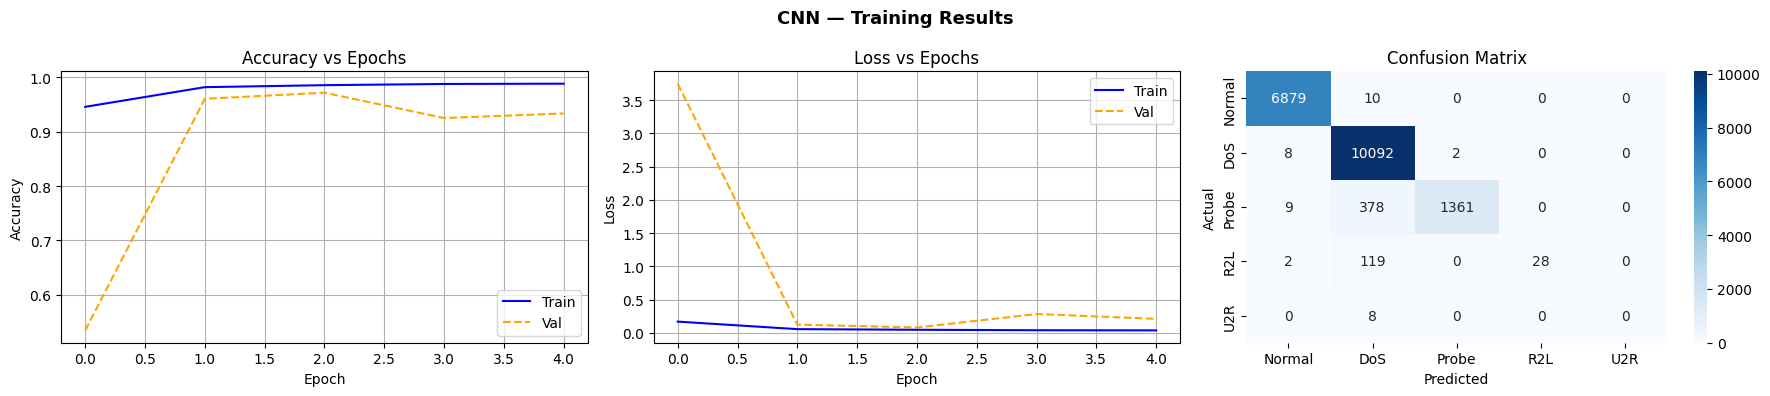

  Plot saved as results_CNN.png


In [58]:
# ── EVALUATE CNN ─────────────────────────────────────────────────────────────
evaluate_model(cnn_model, X_val_3d, y_val, y_val_cat, "CNN", cnn_history)


## 🟠 Model 2 — RNN (Recurrent Neural Network using LSTM cells)

**How RNN works for this problem:**
- Reads the 41 features **one by one**, like reading a sentence word by word
- Has a **memory** — remembers what it saw in earlier features while reading later ones
- Can link `feature[2]` with `feature[38]` if they are related
- We use **LSTM** cells (a smarter type of RNN that handles long sequences better)


In [59]:
# ── BUILD RNN (LSTM) MODEL ───────────────────────────────────────────────────

inp = Input(shape=INPUT_SHAPE, name="rnn_input")

# LSTM reads features as a sequence, one step at a time
# return_sequences=True  → pass output of each step to next layer
# return_sequences=False → only pass final output
x = layers.LSTM(128, return_sequences=True)(inp)
x = layers.Dropout(0.3)(x)

x = layers.LSTM(64, return_sequences=False)(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)

output = layers.Dense(NUM_CLASSES, activation="softmax")(x)

rnn_model = Model(inputs=inp, outputs=output, name="RNN_LSTM_Model")
rnn_model.summary()


Model: "RNN_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_input (InputLayer)          │ (None, 41, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 41, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 41, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,453 (470.52 KB)

 Trainable params: 120,453 (470.52 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
# ── COMPILE RNN ──────────────────────────────────────────────────────────────
rnn_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ── TRAIN RNN ────────────────────────────────────────────────────────────────
print("Training RNN model... (LSTM is slower, please wait)")

rnn_history = rnn_model.fit(
    X_train_3d, y_train_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=5,
    batch_size=256,
    callbacks=[get_early_stop()],
    verbose=1
)

print("\n✅ RNN training complete!")


Training RNN model... (LSTM is slower, please wait)
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 127s 293ms/step - accuracy: 0.9178 - loss: 0.2699 - val_accuracy: 0.9553 - val_loss: 0.1131
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 124s 295ms/step - accuracy: 0.9687 - loss: 0.0976 - val_accuracy: 0.9730 - val_loss: 0.0847
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 122s 291ms/step - accuracy: 0.9751 - loss: 0.0791 - val_accuracy: 0.9794 - val_loss: 0.0629
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 122s 292ms/step - accuracy: 0.9800 - loss: 0.0642 - val_accuracy: 0.9582 - val_loss: 0.1134
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 123s 294ms/step - accuracy: 0.9816 - loss: 0.0572 - val_accuracy: 0.9858 - val_loss: 0.0426
Restoring model weights from the end of the best epoch: 5.

✅ RNN training complete!



  RNN Results
  ✅ Accuracy : 98.58%

── Per-Class Report ──────────────────────────────────
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6889
         DoS       0.98      0.99      0.99     10102
       Probe       0.97      0.96      0.96      1748
         R2L       0.77      0.45      0.57       149
         U2R       0.00      0.00      0.00         8

    accuracy                           0.99     18896
   macro avg       0.74      0.68      0.70     18896
weighted avg       0.98      0.99      0.98     18896



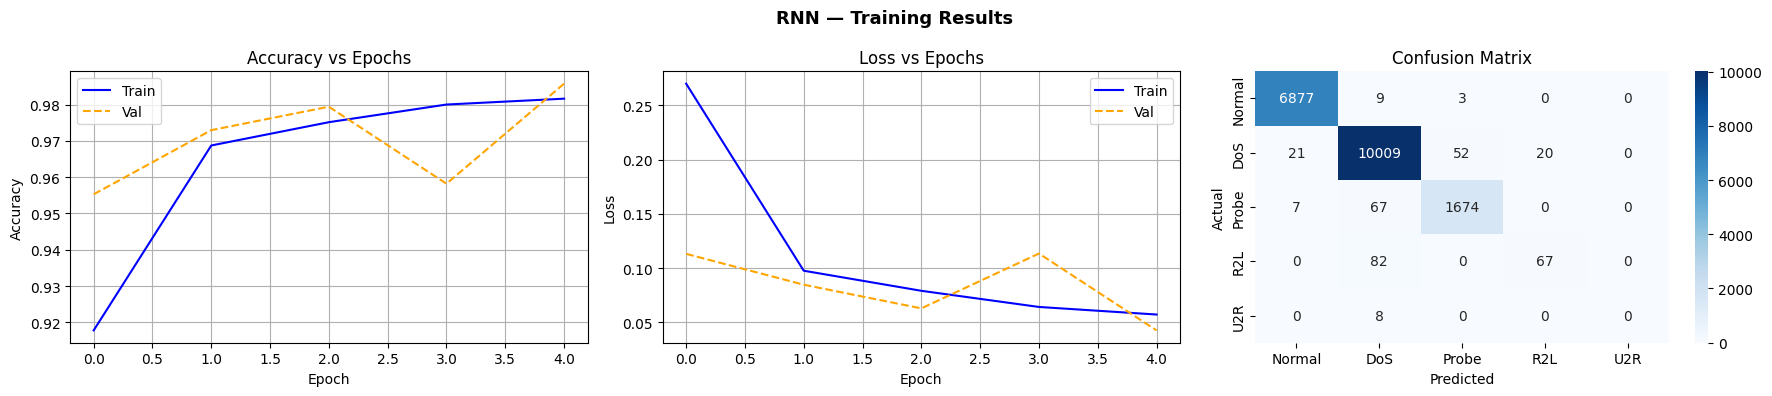

  Plot saved as results_RNN.png


In [61]:
# ── EVALUATE RNN ─────────────────────────────────────────────────────────────
evaluate_model(rnn_model, X_val_3d, y_val, y_val_cat, "RNN", rnn_history)


## 🟢 Model 3 — CNN + LSTM (Combined Model)

**How the combination works:**
- The **same input** goes into both CNN and LSTM at the same time
- CNN finds **local patterns** between nearby features
- LSTM finds **long-range relationships** across all features
- Their outputs are **joined together**
- A final Dense layer makes the prediction using both CNN and LSTM knowledge

```
Input Features
     │
  ┌──┴──┐
  ▼     ▼
 CNN   LSTM
  │     │
  └──┬──┘
     │  ← joined (Concatenate)
     ▼
 Dense Layer
     │
     ▼
Normal / DoS / Probe / R2L / U2R
```


In [62]:
# ── BUILD CNN + LSTM COMBINED MODEL ─────────────────────────────────────────

inp = Input(shape=INPUT_SHAPE, name="combined_input")

# ── CNN Branch : finds local feature patterns ────────────────────────────────
cnn_branch = layers.Conv1D(64,  kernel_size=3, activation="relu", padding="same")(inp)
cnn_branch = layers.BatchNormalization()(cnn_branch)
cnn_branch = layers.Conv1D(32,  kernel_size=3, activation="relu", padding="same")(cnn_branch)
cnn_branch = layers.GlobalAveragePooling1D()(cnn_branch)   # shape becomes (32,)
cnn_branch = layers.Dropout(0.3)(cnn_branch)

# ── LSTM Branch : reads features as sequence with memory ─────────────────────
lstm_branch = layers.LSTM(64, return_sequences=False)(inp)
lstm_branch = layers.Dropout(0.3)(lstm_branch)
lstm_branch = layers.Dense(32, activation="relu")(lstm_branch)  # shape becomes (32,)

# ── Join CNN + LSTM outputs ──────────────────────────────────────────────────
#   CNN output  shape : (32,)
#   LSTM output shape : (32,)
#   After joining     : (64,)  ← combined knowledge of both
combined = layers.Concatenate(name="join_cnn_lstm")([cnn_branch, lstm_branch])

combined = layers.Dense(64, activation="relu")(combined)
combined = layers.Dropout(0.2)(combined)

output = layers.Dense(NUM_CLASSES, activation="softmax")(combined)

cnn_lstm_model = Model(inputs=inp, outputs=output, name="CNN_LSTM_Model")
cnn_lstm_model.summary()


Model: "CNN_LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ combined_input      │ (None, 41, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 41, 64)    │        256 │ combined_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 41, 64)    │        256 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 41, 32)    │      6,176 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     16,896 │ combined_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv1d_13[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 64)        │          0 │ lstm_2[0][0]      │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      2,080 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ join_cnn_lstm       │ (None, 64)        │          0 │ dropout_11[0][0], │
│ (Concatenate)       │                   │            │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 64)        │      4,160 │ join_cnn_lstm[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 5)         │        325 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,149 (117.77 KB)

 Trainable params: 30,021 (117.27 KB)

 Non-trainable params: 128 (512.00 B)

In [63]:
# ── COMPILE CNN+LSTM ─────────────────────────────────────────────────────────
cnn_lstm_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# ── TRAIN CNN+LSTM ───────────────────────────────────────────────────────────
print("Training CNN+LSTM combined model...")

cnn_lstm_history = cnn_lstm_model.fit(
    X_train_3d, y_train_cat,
    validation_data=(X_val_3d, y_val_cat),
    epochs=5,
    batch_size=256,
    callbacks=[get_early_stop()],
    verbose=1
)

print("\n✅ CNN+LSTM training complete!")


Training CNN+LSTM combined model...
Epoch 1/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 49s 108ms/step - accuracy: 0.9097 - loss: 0.2806 - val_accuracy: 0.9648 - val_loss: 0.1076
Epoch 2/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.9666 - loss: 0.1037 - val_accuracy: 0.9740 - val_loss: 0.0787
Epoch 3/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9727 - loss: 0.0842 - val_accuracy: 0.9765 - val_loss: 0.0695
Epoch 4/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9764 - loss: 0.0715 - val_accuracy: 0.9800 - val_loss: 0.0581
Epoch 5/5
419/419 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - accuracy: 0.9793 - loss: 0.0640 - val_accuracy: 0.9825 - val_loss: 0.0504
Restoring model weights from the end of the best epoch: 5.

✅ CNN+LSTM training complete!



  CNN+LSTM Results
  ✅ Accuracy : 98.25%

── Per-Class Report ──────────────────────────────────
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      6889
         DoS       0.98      0.98      0.98     10102
       Probe       0.93      0.96      0.94      1748
         R2L       0.82      0.44      0.57       149
         U2R       0.00      0.00      0.00         8

    accuracy                           0.98     18896
   macro avg       0.75      0.68      0.70     18896
weighted avg       0.98      0.98      0.98     18896



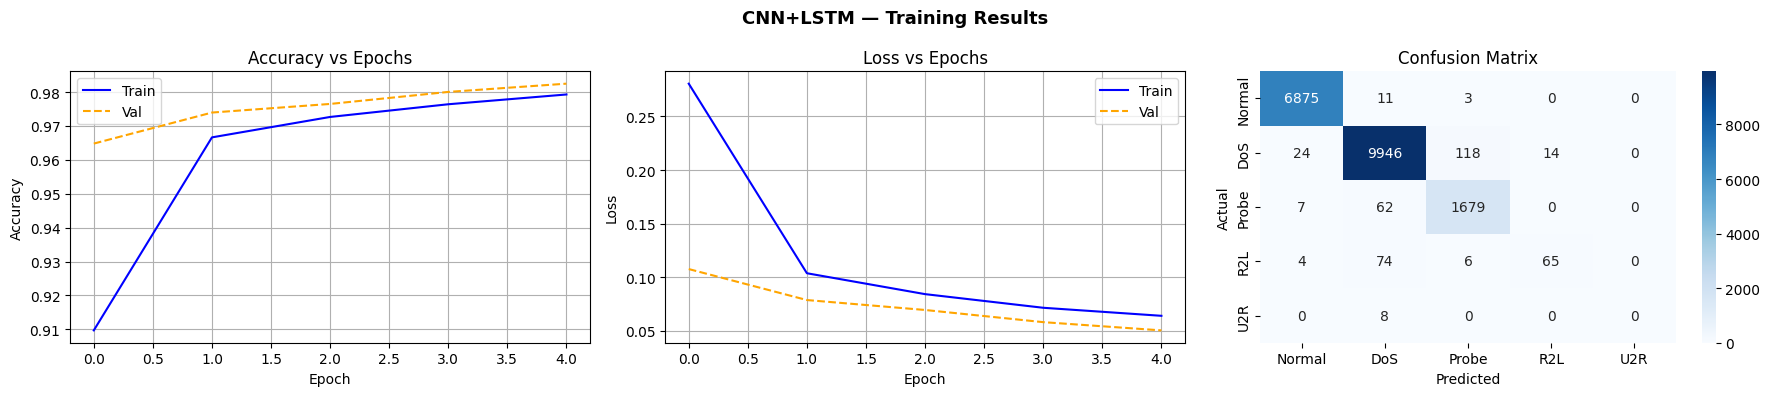

  Plot saved as results_CNN+LSTM.png


In [64]:
# ── EVALUATE CNN+LSTM ────────────────────────────────────────────────────────
evaluate_model(cnn_lstm_model, X_val_3d, y_val, y_val_cat, "CNN+LSTM", cnn_lstm_history)


## 📊 Final Comparison — All 3 Models Side by Side

Which model performed best?


In [65]:
# ── PRINT COMPARISON TABLE ───────────────────────────────────────────────────
print("\n" + "="*45)
print("   FINAL MODEL COMPARISON")
print("="*45)
print(f"  {'Model':<15} {'Accuracy':>10}")
print(f"  {'-'*30}")
for model_name, acc in all_results.items():
    print(f"  {model_name:<15} {acc:>9.2f}%")
print("="*45)
best = max(all_results, key=all_results.get)
print(f"\n  🏆 Best Model : {best} ({all_results[best]:.2f}%)")



   FINAL MODEL COMPARISON
  Model             Accuracy
  ------------------------------
  CNN                 97.16%
  RNN                 98.58%
  CNN+LSTM            98.25%

  🏆 Best Model : RNN (98.58%)


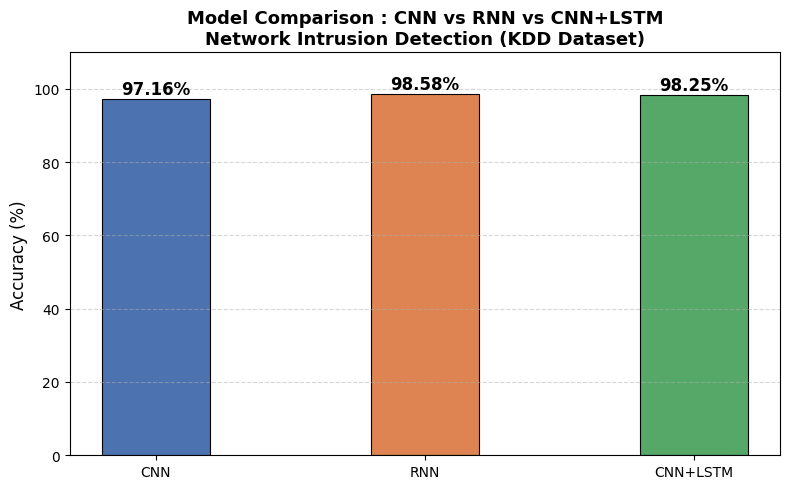

✅ Comparison chart saved as model_comparison.png


In [66]:
# ── BAR CHART COMPARISON ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

models  = list(all_results.keys())
accuracies = list(all_results.values())
colors  = ["#4C72B0", "#DD8452", "#55A868"]   # blue, orange, green

bars = ax.bar(models, accuracies, color=colors, width=0.4, edgecolor="black", linewidth=0.8)

# Show accuracy value on top of each bar
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{acc:.2f}%",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 110)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Model Comparison : CNN vs RNN vs CNN+LSTM\nNetwork Intrusion Detection (KDD Dataset)",
             fontsize=13, fontweight="bold")
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("✅ Comparison chart saved as model_comparison.png")


## ✅ Done!

**What you built:**
| Model | What it does |
|-------|-------------|
| **CNN** | Finds patterns between nearby features using sliding windows |
| **RNN (LSTM)** | Reads features like a sequence, remembers connections |
| **CNN + LSTM** | Combines both — usually the best performer |

**Output classes detected:**
- `Normal` — regular network traffic
- `DoS` — Denial of Service attack (e.g. neptune, smurf)
- `Probe` — Scanning/probing attack (e.g. nmap, ipsweep)
- `R2L` — Remote to Local attack (e.g. guess_passwd)
- `U2R` — User to Root attack (e.g. buffer_overflow)
